## Clickbait Pre-processing

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from string import punctuation
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split

nltk.download('punkt')
nltk.download('stopwords')

/home/pradyumna/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
[nltk_data] Downloading package punkt to /home/pradyumna/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/pradyumna/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Loading dataset

In [2]:
Clickbait_df = pd.read_csv('clickbait_data.csv')
Clickbait_df

,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer...",1
3,"This Vine Of New York On ""Celebrity Big Brothe...",1
4,A Couple Did A Stunning Photo Shoot With Their...,1
...,...,...
31995,"To Make Female Hearts Flutter in Iraq, Throw a...",0
31996,"British Liberal Democrat Patsy Calton, 56, die...",0
31997,Drone smartphone app to help heart attack vict...,0
31998,"Netanyahu Urges Pope Benedict, in Israel, to D...",0


### Lowercase the words

In [3]:
Clickbait_df['headline']=Clickbait_df['headline'].apply(lambda x: x.lower())
Clickbait_df.head()

,headline,clickbait
0,should i get bings,1
1,which tv female friend group do you belong in,1
2,"the new ""star wars: the force awakens"" trailer...",1
3,"this vine of new york on ""celebrity big brothe...",1
4,a couple did a stunning photo shoot with their...,1


### Tokenization

In [4]:
def tokenize(text):
    Text = text.split()
    return Text

In [5]:
Clickbait_df['headline']=Clickbait_df['headline'].apply(tokenize)
Clickbait_df.head()

,headline,clickbait
0,"[should, i, get, bings]",1
1,"[which, tv, female, friend, group, do, you, be...",1
2,"[the, new, ""star, wars:, the, force, awakens"",...",1
3,"[this, vine, of, new, york, on, ""celebrity, bi...",1
4,"[a, couple, did, a, stunning, photo, shoot, wi...",1


### Remove punctuation

In [6]:
def remove_punctuation(words):
    new_words = []
    for text in words: 
        for punctuation in string.punctuation:
            text = text.replace(punctuation, '')
        new_words.append(text)
    return new_words

In [7]:
Clickbait_df['headline']=Clickbait_df['headline'].apply(remove_punctuation)
Clickbait_df.head()

,headline,clickbait
0,"[should, i, get, bings]",1
1,"[which, tv, female, friend, group, do, you, be...",1
2,"[the, new, star, wars, the, force, awakens, tr...",1
3,"[this, vine, of, new, york, on, celebrity, big...",1
4,"[a, couple, did, a, stunning, photo, shoot, wi...",1


### Remove stopwords

In [8]:
stop_words = set(stopwords.words("english"))
def remove_stopwords(words):
    new_words=[]
    for text in words:
        if text not in stop_words:
            new_words.append(text)
    return new_words

In [9]:
Clickbait_df['headline']=Clickbait_df['headline'].apply(remove_stopwords)
Clickbait_df.head()

,headline,clickbait
0,"[get, bings]",1
1,"[tv, female, friend, group, belong]",1
2,"[new, star, wars, force, awakens, trailer, giv...",1
3,"[vine, new, york, celebrity, big, brother, fuc...",1
4,"[couple, stunning, photo, shoot, baby, learnin...",1


### Remove numbers and space

In [10]:
def text_cleaning(words):
    new_words = []
    for text in words:
        result = re.sub('\w*\d+\w*', ' ', text)
        result = re.sub(r'\d+',' ', text)
        result = re.sub(' +', ' ', result).strip()

        if(result != ""):
            new_words.append(result)
    return new_words
    

In [11]:
Clickbait_df['headline']=Clickbait_df['headline'].apply(text_cleaning)
Clickbait_df.head()

,headline,clickbait
0,"[get, bings]",1
1,"[tv, female, friend, group, belong]",1
2,"[new, star, wars, force, awakens, trailer, giv...",1
3,"[vine, new, york, celebrity, big, brother, fuc...",1
4,"[couple, stunning, photo, shoot, baby, learnin...",1


### Save Processed data into .csv file

In [12]:
# Create test-train sets
text = Clickbait_df.drop(columns='clickbait')
Class = Clickbait_df['clickbait']
X_train, X_test, y_train, y_test = train_test_split(text, Class)

Clickbait_df.to_csv('Processed_data.csv')
X_train.to_csv('X_train.csv')
X_test.to_csv('X_test.csv')
y_train.to_csv('y_train.csv')
y_test.to_csv('y_test.csv')

In [13]:
Clickbait_df.head()

,headline,clickbait
0,"[get, bings]",1
1,"[tv, female, friend, group, belong]",1
2,"[new, star, wars, force, awakens, trailer, giv...",1
3,"[vine, new, york, celebrity, big, brother, fuc...",1
4,"[couple, stunning, photo, shoot, baby, learnin...",1


In [14]:
df_cb = Clickbait_df[Clickbait_df['clickbait']==1]

df_noncb = Clickbait_df[Clickbait_df['clickbait']==0]

print("Non-Clickbait \n",df_noncb.count())
print("Clickbait \n",df_cb.count())

Non-Clickbait 
 headline     16001
clickbait    16001
dtype: int64
Clickbait 
 headline     15999
clickbait    15999
dtype: int64


In [15]:
cb = list(df_cb['headline']) 
noncv = list(df_noncb['headline'])
flat_cb = [item for sublist in cb for item in sublist]
flat_noncb = [item for sublist in noncv for item in sublist]
cb_frequent = FreqDist(flat_cb)
noncb_frequent = FreqDist(flat_noncb)

In [16]:
# top 20 clickbait words
cb_frequent.most_common(20)

[('things', 997),
 ('people', 914),
 ('know', 803),
 ('make', 760),
 ('based', 607),
 ('actually', 596),
 ('times', 508),
 ('like', 490),
 ('best', 470),
 ('new', 442),
 ('heres', 423),
 ('need', 403),
 ('life', 387),
 ('every', 332),
 ('ever', 330),
 ('get', 317),
 ('time', 311),
 ('youre', 299),
 ('zodiac', 295),
 ('one', 295)]

In [17]:
# top 20 non-clickbait words 
noncb_frequent.most_common(20)

[('us', 1172),
 ('new', 803),
 ('dead', 350),
 ('dies', 347),
 ('killed', 346),
 ('president', 297),
 ('uk', 292),
 ('kills', 277),
 ('wins', 271),
 ('australian', 270),
 ('first', 269),
 ('says', 269),
 ('two', 250),
 ('obama', 249),
 ('police', 241),
 ('court', 229),
 ('china', 227),
 ('world', 225),
 ('iraq', 225),
 ('british', 223)]

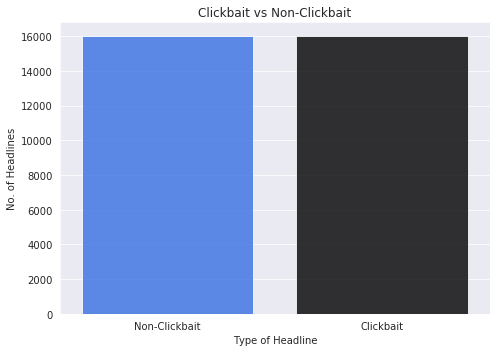

In [18]:
#class variable countplot
#visualizing class frequency of dataset
sns.set_style('darkgrid')
plt.figure(figsize=(7,5))
fig1=sns.countplot(x=Clickbait_df['clickbait'], alpha =.80, palette= ['#1a66ff','black'])
plt.title('Clickbait vs Non-Clickbait')
plt.ylabel('No. of Headlines')
plt.xlabel('Type of Headline')
fig1.set(xticklabels=['Non-Clickbait','Clickbait'])
plt.tight_layout()
plt.savefig('class_dist')
plt.show()

In [19]:
# create counts of clickbait and non-clickbait words and values
cb_bar_counts = [x[1] for x in cb_frequent.most_common(20)]
cb_bar_words = [x[0] for x in cb_frequent.most_common(20)]

noncb_bar_counts = [x[1] for x in noncb_frequent.most_common(20)]
noncb_bar_words = [x[0] for x in noncb_frequent.most_common(20)]

plt.style.use('seaborn-talk')


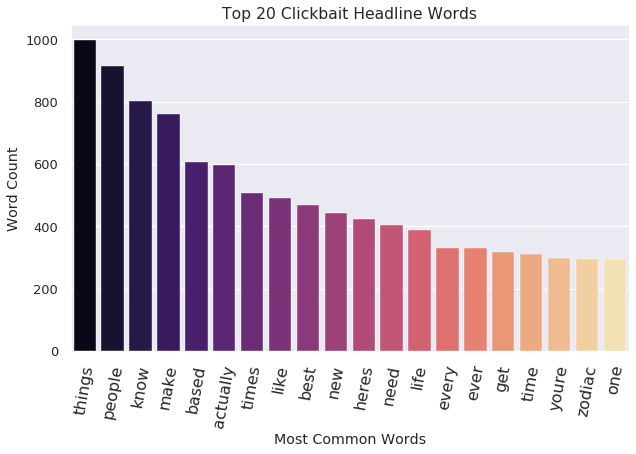

In [20]:
#bar plot for top 15 most common clickbait words
word_freq_figure1 = plt.figure(figsize=(10,6))
sns.barplot(x=cb_bar_words, y=cb_bar_counts,palette='magma')
plt.xticks(fontsize=16)
plt.xticks(rotation=80)
plt.title('Top 20 Clickbait Headline Words')
plt.xlabel('Most Common Words')
plt.ylabel('Word Count')
sns.set_style('white')
plt.show()

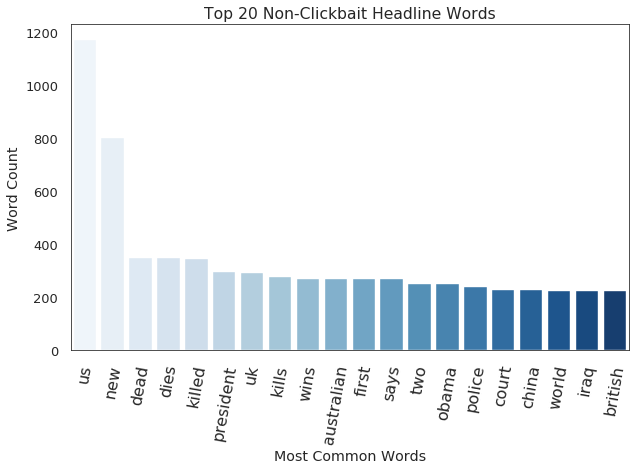

In [21]:
#bar plot for top 15 most common non-clickbait words
word_freq_figure1 = plt.figure(figsize=(10,6))
sns.barplot(x=noncb_bar_words, y=noncb_bar_counts,palette='Blues')
plt.xticks(fontsize=16)
plt.xticks(rotation=80)
plt.title('Top 20 Non-Clickbait Headline Words')
plt.xlabel('Most Common Words')
plt.ylabel('Word Count')
sns.set_style()
plt.show()

In [22]:
clickbait_dictionary = dict(zip(cb_bar_words, cb_bar_counts))
nonclickbait_dictionary = dict(zip(noncb_bar_words, noncb_bar_counts))

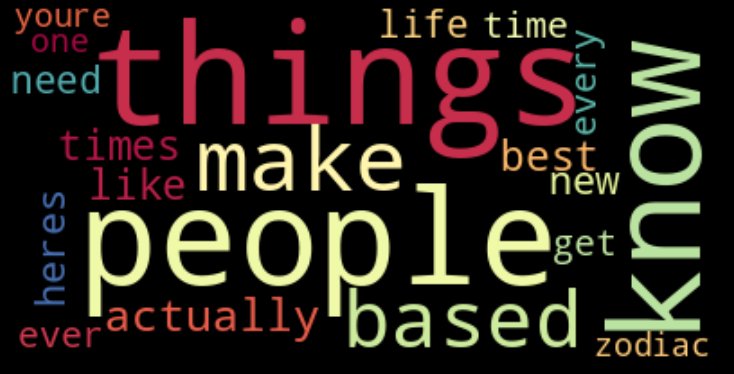

In [23]:
# Create the clickbait word cloud:

wordcloud = WordCloud(colormap='Spectral').generate_from_frequencies(clickbait_dictionary)

# Display the generated image w/ matplotlib:

plt.figure(figsize=(10,10), facecolor='k')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)

# Uncomment the next line if you want to save your image:

plt.savefig('clickbait_wc')

plt.show()

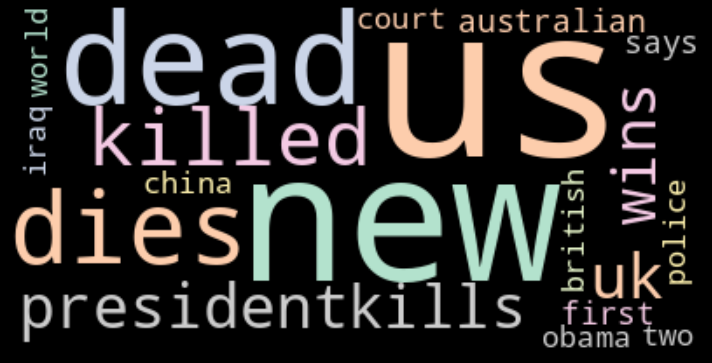

In [24]:
# Create the non-clickbait word cloud:

wordcloud = WordCloud(colormap='Pastel2').generate_from_frequencies(nonclickbait_dictionary)

# Display the generated image w/ matplotlib:

plt.figure(figsize=(10,10), facecolor='k')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)

# Uncomment the next line if you want to save your image:
plt.tight_layout()
plt.savefig('clickbait_wc')

plt.show()